# The Gradient: Which Way Is Uphill?

**This notebook is self-contained; it recaps partial derivatives before combining them.**

The two partial derivatives give the slope along the $x$ axis and along the $y$ axis. But standing on
a hillside you rarely want to walk due east or due north, you want to know which way is **steepest**.

Collect the two partials into a single vector and you get exactly that. The **gradient** points
straight uphill, and its length says how steep the climb is. This is the object gradient descent walks
against, so the picture built here is the one the next section animates.

## Learning objectives

- Assemble the partial derivatives into the **gradient vector** $\nabla f$.
- Interpret its **direction** as steepest ascent and its **length** as steepness.
- Read a **gradient field** on a contour map, and see that the arrows meet the contours at right angles.

## Background

For $f(x, y)$, the **gradient** is the column vector of its partial derivatives:

$$\nabla f(x,y) = \begin{bmatrix} \partial f / \partial x \\ \partial f / \partial y \end{bmatrix}$$

(The symbol $\nabla$ is said "del" or "grad".) Two facts make it useful, and both are worth holding
onto:

1. **$\nabla f$ points in the direction of steepest ascent**, the compass bearing of the fastest way up.
2. **Its magnitude $\lVert \nabla f \rVert$ is how steep that is.** A long arrow means a cliff; a short
   one means nearly flat ground.

A third fact follows and is visually striking: the gradient is always **perpendicular to the contour
lines**. Contours join points of equal height, so moving along one gains no altitude at all, and the
fastest way up must be exactly at right angles to the direction that gains nothing.

At a maximum, minimum, or saddle the surface is flat in every direction, so $\nabla f = \mathbf{0}$.
That is the multivariable version of §3.5's $f'(x) = 0$.

## This notebook covers

1. Building the gradient at a point.
2. The gradient field over a contour map.
3. Perpendicular to the contours.
4. Where the gradient vanishes.

**Prerequisites:** `U3-6_Multivariable-2_PartialDerivatives`

**Dataset:** none, functions are entered directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
# plotting helper: draw one vector as an arrow starting at `tail`
# (zorder keeps arrows on top of the axis spines, which are the same white)
def arrow(ax, tail, vec, color, label=None, alpha=1.0):
    ax.quiver(tail[0], tail[1], vec[0], vec[1], angles='xy', scale_units='xy',
              scale=1, color=color, label=label, alpha=alpha, width=0.011, zorder=5)

## 1. The gradient at a point

Take the bowl $f(x,y) = x^2 + y^2$ again, whose partials are $2x$ and $2y$. At the point $(2, 1)$:

$$\nabla f(2, 1) = \begin{bmatrix} 2(2) \\ 2(1) \end{bmatrix} = \begin{bmatrix} 4 \\ 2 \end{bmatrix}$$

It is a **vector**, a column, per the convention from Unit 2, so we display it as one. It points up
and to the right, away from the bowl's low point at the origin, which is exactly the uphill direction
there.

In [2]:
def f(x, y):
    return x**2 + y**2

def grad_f(x, y):
    return np.array([2*x, 2*y])          # [df/dx, df/dy], stacked as a column

point = (2.0, 1.0)
g = grad_f(*point)

helpers.show(g, name=r"\nabla f(2, 1)")
print(f"direction: up and to the right")
print(f"steepness: ||grad f|| = {np.linalg.norm(g):.4f}")
print()
# is it really the steepest direction? try walking a small step several ways and compare
step = 0.01
print("gain in height for a small step in various directions:")
for angle in range(0, 360, 45):
    d = np.array([math.cos(math.radians(angle)), math.sin(math.radians(angle))])
    gain = f(point[0] + step*d[0], point[1] + step*d[1]) - f(*point)
    marker = "  <- the gradient direction" if abs(angle - math.degrees(math.atan2(g[1], g[0]))) < 23 else ""
    print(f"   heading {angle:3d} deg: {gain:+.6f}{marker}")

<IPython.core.display.Math object>

direction: up and to the right
steepness: ||grad f|| = 4.4721

gain in height for a small step in various directions:
   heading   0 deg: +0.040100
   heading  45 deg: +0.042526  <- the gradient direction
   heading  90 deg: +0.020100
   heading 135 deg: -0.014042
   heading 180 deg: -0.039900
   heading 225 deg: -0.042326
   heading 270 deg: -0.019900
   heading 315 deg: +0.014242


The largest gain is in the direction the gradient points. That is not a coincidence, it is the
defining property.

## 2. The gradient field

Compute the gradient at every point of a grid and draw each one as an arrow. The result is a
**gradient field**, laid over the contour map from the previous notebook.

Every arrow points away from the bowl's minimum, and the arrows get **longer** as you move outward, the bowl gets steeper the further you are from the bottom.

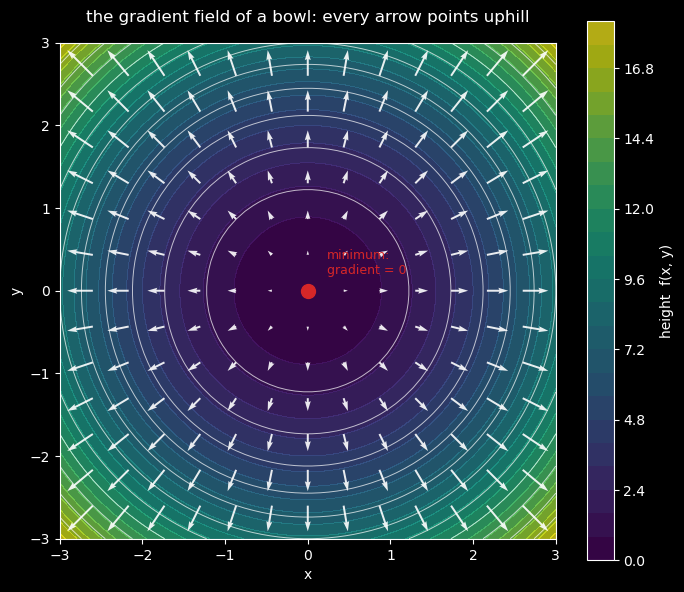

In [3]:
n = 60
xs = np.linspace(-3, 3, n)
ys = np.linspace(-3, 3, n)
X, Y = np.meshgrid(xs, ys)
Z = f(X, Y)

# a coarser grid for the arrows, so they stay readable
xa = np.linspace(-2.6, 2.6, 13)
ya = np.linspace(-2.6, 2.6, 13)
XA, YA = np.meshgrid(xa, ya)
U, V = 2*XA, 2*YA

fig, ax = plt.subplots(figsize=(8, 7))
cs = ax.contourf(X, Y, Z, levels=25, cmap="viridis", alpha=0.75)
ax.contour(X, Y, Z, levels=12, colors="white", linewidths=0.7, alpha=0.7)
ax.quiver(XA, YA, U, V, color="white", alpha=0.9, width=0.004)
fig.colorbar(cs, ax=ax, label="height  f(x, y)")

ax.plot(0, 0, "o", color="tab:red", markersize=10)
ax.annotate("minimum:\ngradient = 0", (0, 0), textcoords="offset points",
            xytext=(14, 12), color="tab:red", fontsize=9)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_aspect("equal")
ax.set_title("the gradient field of a bowl: every arrow points uphill", pad=15)
plt.show()

## 3. Perpendicular to the contours

Zoom in on a single point and draw three things: the contour line through it, the gradient arrow, and
the direction *along* the contour. The gradient meets the contour at a **right angle**.

The reasoning is worth stating plainly: walking along a contour keeps your height constant, so that
direction gains nothing. The steepest-ascent direction has to be as far from "gains nothing" as
possible, a full 90° away.

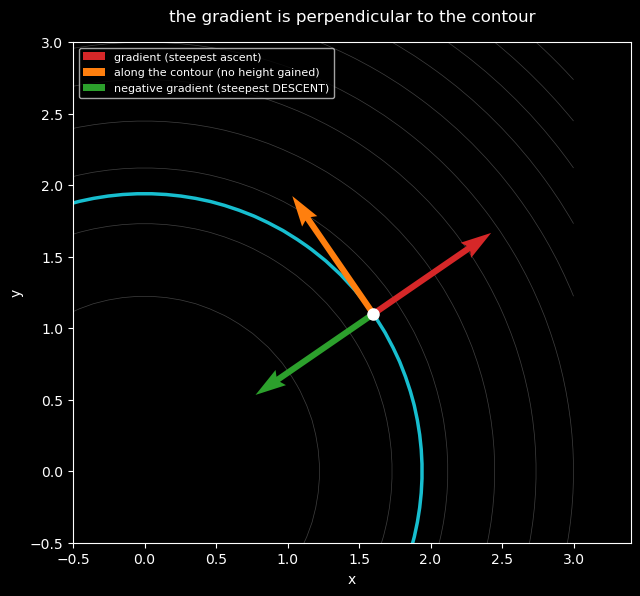

angle between the gradient and the contour direction: 0.0 + 90.0 = 90 degrees
dot product (zero means perpendicular): 0.00e+00


In [4]:
p = np.array([1.6, 1.1])
gp = grad_f(*p)
gp_unit = gp / np.linalg.norm(gp)
along_contour = np.array([-gp_unit[1], gp_unit[0]])     # rotate the gradient a quarter turn

fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.contour(X, Y, Z, levels=[f(*p)], colors="tab:cyan", linewidths=2.5)
ax.contour(X, Y, Z, levels=14, colors="gray", linewidths=0.5, alpha=0.5)

arrow(ax, p, gp_unit * 1.0, "tab:red", "gradient (steepest ascent)")
arrow(ax, p, along_contour * 1.0, "tab:orange", "along the contour (no height gained)")
arrow(ax, p, -gp_unit * 1.0, "tab:green", "negative gradient (steepest DESCENT)")
ax.plot(*p, "o", color="white", markersize=8, zorder=6)

angle = math.degrees(math.acos(abs(np.dot(gp_unit, along_contour))))
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_xlim(-0.5, 3.4); ax.set_ylim(-0.5, 3.0)
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=8)
ax.set_title("the gradient is perpendicular to the contour", pad=15)
plt.show()

print(f"angle between the gradient and the contour direction: {90 - angle:.1f} + {angle:.1f} = 90 degrees")
print(f"dot product (zero means perpendicular): {np.dot(gp_unit, along_contour):.2e}")

Note the **green** arrow: the *negative* gradient, pointing steepest **downhill**. That is the
direction an optimizer wants to move when it is minimizing something, and it is the entire idea of
gradient descent in the next section.

## 4. Where the gradient vanishes

At a minimum, maximum, or saddle, the surface is flat in every direction, so both partials are zero
and $\nabla f = \mathbf{0}$. This is exactly §3.5's condition $f'(x) = 0$, promoted to two variables.

The saddle is the interesting case. Its gradient vanishes at the origin just like the bowl's, but the
field around it looks completely different: arrows flow *away* along one axis and *toward* it along the
other. A vanishing gradient tells you the ground is flat, not that you have found a minimum.

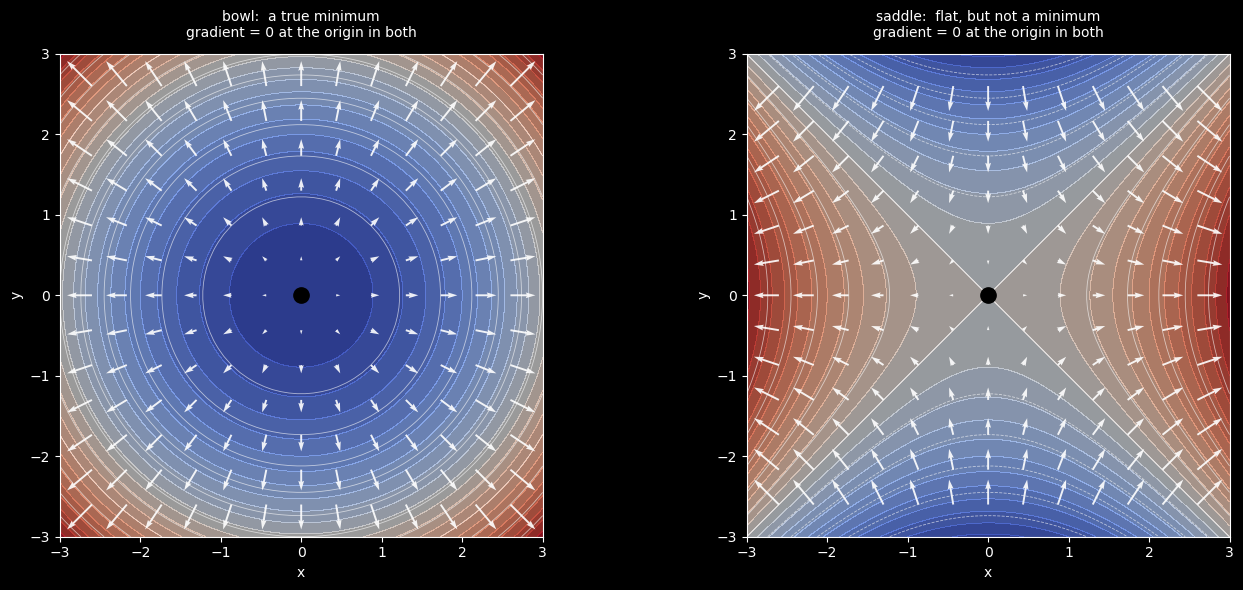

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
def saddle(x, y):
    return x**2 - y**2

Zs = saddle(X, Y)
Us, Vs = 2*XA, -2*YA           # gradient of x^2 - y^2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, U_, V_, name in [(axes[0], Z, U, V, "bowl:  a true minimum"),
                               (axes[1], Zs, Us, Vs, "saddle:  flat, but not a minimum")]:
    cs = ax.contourf(X, Y, data, levels=25, cmap="coolwarm", alpha=0.7)
    ax.contour(X, Y, data, levels=12, colors="white", linewidths=0.6, alpha=0.6)
    ax.quiver(XA, YA, U_, V_, color="white", alpha=0.9, width=0.004)
    ax.plot(0, 0, "o", color="black", markersize=11, zorder=6)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.set_title(name + "\ngradient = 0 at the origin in both", pad=12, fontsize=10)
plt.tight_layout()
plt.show()

helpers.show(grad_f(0, 0), label="gradient of the bowl at the origin")
helpers.show(np.array([2*0.0, -2*0.0]), label="gradient of the saddle at the origin")

Both gradients vanish, and only one of the two points is a minimum. **A zero gradient alone is not enough**, it says the ground is flat, not that you have found the bottom.


## 5. Summary

- The **gradient** $\nabla f = \begin{bmatrix}\partial f/\partial x \\ \partial f/\partial y\end{bmatrix}$
  stacks the partials into a vector.
- It points in the direction of **steepest ascent**; its **length** is how steep.
- It is always **perpendicular to the contour lines**, because moving along a contour gains no height.
- The **negative** gradient points steepest downhill, the direction an optimizer moves.
- $\nabla f = \mathbf{0}$ at minima, maxima, **and saddles**; flat ground alone does not mean you have
  found a minimum.

Next: actually walking downhill, one step at a time, to minimize a function nobody can solve by algebra
(`U3-7_GradientDescent-1_Descent`).